In [1]:
"""
Answer Notebook for Capstone Project
Learn Python the Biologist's Way

This notebook provides code-based solutions for the
Capstone Project.

The solutions presented here are sample approaches
and may not be the only valid ways to solve these
problems. Readers are encouraged to explore
alternative approaches and adapt the code as needed.

The book purchase link and additional resources are
available on the GitHub repository landing page

Author: Dr. Prince Kumar Lat
"""

!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 38.3 MB/s eta 0:00:00


# Part 1

In [2]:
def create_literature_summary(papers, filename):
    """
    Save PubMed article information into a text file.

    Parameters:
    papers (list): List of dictionaries containing article information
    filename (str): Name of the output text file

    Returns:
    None
    """

    with open(filename, "w", encoding="utf-8") as f:

        f.write("Literature Summary: EGFR-related PubMed Articles\n")
        f.write("=" * 60 + "\n\n")

        for i, paper in enumerate(papers, start=1):

            f.write(f"Article {i}\n")
            f.write("-" * 40 + "\n")

            f.write(f"PubMed ID: {paper['pubmed_id']}\n")
            f.write(f"Title: {paper['title']}\n")

            f.write("Authors:\n")
            if isinstance(paper["authors"], list):
                f.write(", ".join(paper["authors"]) + "\n")
            else:
                f.write(f"{paper['authors']}\n")

            f.write(f"Journal: {paper['journal']}\n")
            f.write(f"Year: {paper['year']}\n\n")

            f.write("Abstract:\n")
            f.write(f"{paper['abstract']}\n")

            f.write("\n" + "=" * 60 + "\n\n")

    print(f"Literature summary saved as: {filename}")

In [3]:
from Bio import Entrez, Medline

Entrez.email = "prince@redwoodai.com"

database = "pubmed"
gene = "EGFR"
search_term = f"{gene}[Title/Abstract]"
retmax = 10


handle = Entrez.esearch(
    db=database,
    term=search_term,
    retmax=retmax
)

record = Entrez.read(handle)
handle.close()

id_list = record["IdList"]

print(f"Found PubMed IDs: {id_list}")

ids = ",".join(id_list)

handle = Entrez.efetch(
    db=database,
    id=ids,
    rettype="medline",
    retmode="text"
)

records = list(Medline.parse(handle))
handle.close()

papers = []

for rec in records:
    paper = {
        "title": rec.get("TI", "No Title"),
        "authors": rec.get("AU", "No Authors"),
        "journal": rec.get("JT", "No Journal"),
        "year": rec.get("DP", "No Date"),
        "abstract": rec.get("AB", "No Abstract"),
        "pubmed_id": rec.get("PMID", "No PMID")
    }

    papers.append(paper)

print(papers[0])

Found PubMed IDs: ['42490038', '42490000', '42489861', '42489810', '42489683', '42489649', '42489643', '42489252', '42488939', '42488885']
{'title': 'Persistent kidney dysfunction after leptospirosis-associated acute kidney injury: a case series from coastal Karnataka, India.', 'authors': ['Sethi A', 'Prabhu AR', 'Shashidhar V', 'Gupta N'], 'journal': 'International urology and nephrology', 'year': '2026 Jul 23', 'abstract': 'BACKGROUND: Leptospirosis has been infrequently associated with persistent kidney dysfunction fulfilling the criteria for chronic kidney disease (CKD). However, the entity remains poorly characterised. This study aimed to describe the clinical profile, laboratory findings, treatment requirements, and kidney outcomes of patients without recognised CKD risk factors who had persistent kidney dysfunction fulfilling CKD criteria at three-month follow-up after leptospirosis-associated Acute Kidney Injury (AKI). METHODS: This descriptive case series was nested within a p

In [4]:
output_file = "EGFR_PubMed_Summary.txt"

create_literature_summary(
    papers,
    output_file
)

Literature summary saved as: EGFR_PubMed_Summary.txt


# Part 2

In [5]:
# Task 1
from Bio import SeqIO

def calculate_sequence_lengths(filename):
    """
    Calculate the length of each sequence in a FASTA file.

    Parameters:
        filename (str): Path to the FASTA file.

    Returns:
        dict: Dictionary containing sequence headers as keys
              and sequence lengths as values.
    """

    sequence_lengths = {}

    for record in SeqIO.parse(filename, "fasta"):
        sequence_lengths[record.id] = len(record.seq)

    return sequence_lengths

In [6]:
filename = "EGFR.fna"

sequence_lengths = calculate_sequence_lengths(filename)

print(sequence_lengths)

{'NC_000007.14:55019017-55211628': 192612, 'NC_060931.1:55178937-55372056': 193120}


In [7]:
# Task 2
import pandas as pd
from Bio import SeqIO

def calculate_nucleotide_composition(filename):
    """
    Calculate nucleotide composition for each sequence in a FASTA file.

    Parameters:
        filename (str): Path to the FASTA file.

    Returns:
        pandas.DataFrame:
            Rows    -> A, T, C, G
            Columns -> Sequence headers
    """

    nucleotide_counts = {}

    for record in SeqIO.parse(filename, "fasta"):

        sequence = str(record.seq).upper()

        nucleotide_counts[record.id] = {
            "A": sequence.count("A"),
            "T": sequence.count("T"),
            "C": sequence.count("C"),
            "G": sequence.count("G")
        }

    df = pd.DataFrame(nucleotide_counts)

    return df

In [8]:
df_nucleotide = calculate_nucleotide_composition(filename)

print(df_nucleotide)

   NC_000007.14:55019017-55211628  NC_060931.1:55178937-55372056
A                           52532                          52611
T                           54236                          54372
C                           43545                          43562
G                           42299                          42575


In [9]:
# Task 3
import matplotlib.pyplot as plt

def plot_nucleotide_composition(df):
    """
    Create a grouped bar plot showing nucleotide
    composition for each sequence.

    Parameters:
        df (pandas.DataFrame): Nucleotide composition DataFrame.

    Returns:
        None
    """

    ax = df.plot(
        kind="bar",
        figsize=(10, 6),
        width=0.8
    )

    ax.set_title("Nucleotide Composition of EGFR Sequences")
    ax.set_xlabel("Nucleotide")
    ax.set_ylabel("Count")

    plt.xticks(rotation=0)
    plt.legend(title="Sequence")
    plt.tight_layout()
    plt.show()

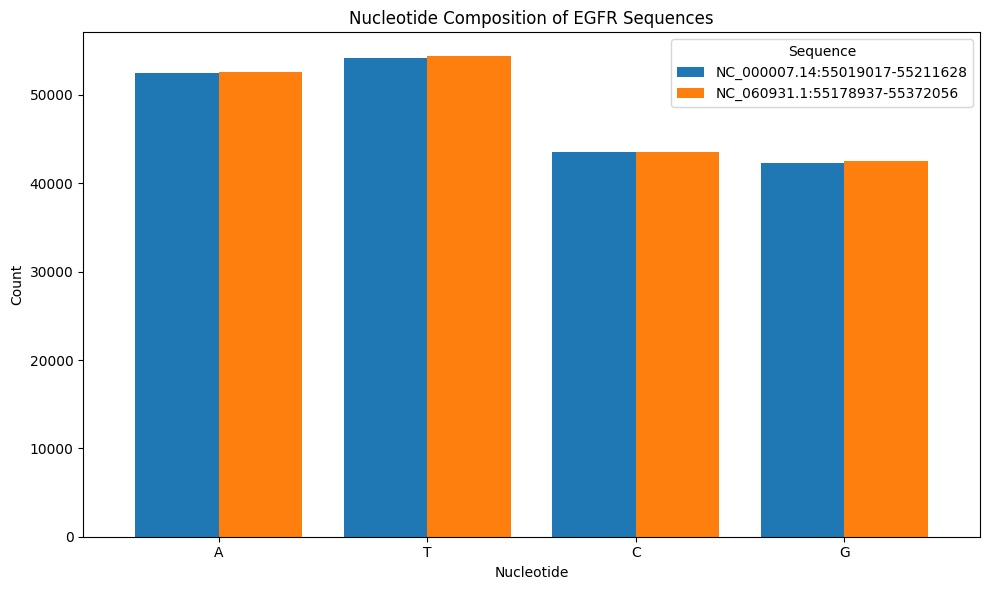

In [10]:
plot_nucleotide_composition(df_nucleotide)

# Part 3

In [11]:
import re
from Bio import SeqIO

In [12]:
def read_fasta(filename):
    """
    Read sequences from a FASTA file.

    Parameters:
        filename (str): FASTA filename.

    Returns:
        dict: Keys are sequence headers and values are DNA sequences.
    """

    sequences = {}

    for record in SeqIO.parse(filename, "fasta"):
        sequences[record.id] = str(record.seq).upper()

    return sequences

In [14]:
filename = "EGFR.fna"

sequences = read_fasta(filename)

In [15]:
def regex_search(sequences, patterns):
    """
    Search multiple regex patterns in multiple DNA sequences.

    Parameters:
        sequences (dict): Dictionary of DNA sequences.
        patterns (dict): Dictionary of regex patterns.

    Returns:
        dict: Search results.
    """

    results = {}

    for header, sequence in sequences.items():

        results[header] = {}

        for name, pattern in patterns.items():

            matches = list(re.finditer(pattern, sequence))

            results[header][name] = {
                "count": len(matches),
                "positions": [m.start() for m in matches],
                "matches": [m.group() for m in matches]
            }

    return results

In [16]:
restriction_patterns = {
    "EcoRI": r"GAATTC",
    "BamHI": r"GGATCC",
    "HindIII": r"AAGCTT",
    "NotI": r"GCGGCCGC"
}

restriction_results = regex_search(
    sequences,
    restriction_patterns
)

print(restriction_results)

{'NC_000007.14:55019017-55211628': {'EcoRI': {'count': 65, 'positions': [3254, 3530, 12605, 21016, 21816, 25811, 27310, 28929, 35573, 36274, 37495, 42125, 43686, 44385, 46634, 47423, 47634, 53984, 56201, 62542, 62779, 65252, 66629, 66673, 74450, 77315, 78076, 80508, 85258, 85959, 88629, 89568, 92579, 97421, 104075, 108706, 110245, 111762, 114536, 118867, 123488, 123820, 124340, 130018, 130719, 137424, 139529, 139815, 141480, 141910, 143333, 145289, 152472, 154973, 162746, 169842, 172018, 172636, 176082, 181349, 187238, 187881, 191952, 192111, 192473], 'matches': ['GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 

In [17]:
homopolymer_patterns = {
    "AAAA": r"AAAA",
    "TTTT": r"TTTT",
    "GGGG": r"GGGG",
    "CCCC": r"CCCC"
}

homopolymer_results = regex_search(
    sequences,
    homopolymer_patterns
)

print(homopolymer_results)

{'NC_000007.14:55019017-55211628': {'AAAA': {'count': 1385, 'positions': [340, 847, 1102, 1433, 1462, 1524, 1869, 1873, 1877, 1884, 1889, 2123, 2448, 2495, 2562, 2592, 3783, 3924, 3929, 4275, 4337, 4383, 4469, 4477, 4481, 4634, 4638, 4642, 4646, 4895, 5467, 6952, 7043, 7315, 7451, 7693, 7722, 7748, 7794, 7832, 7852, 7856, 7866, 7870, 8108, 8240, 8366, 8512, 8519, 8534, 8554, 8629, 8649, 8708, 8762, 8959, 8963, 8967, 8971, 9217, 9249, 9305, 9370, 9470, 9490, 9578, 9720, 9781, 9850, 9978, 9986, 9990, 10140, 10147, 10151, 10482, 10533, 10555, 10577, 10650, 10737, 10777, 10818, 10829, 10835, 10914, 11265, 11461, 11550, 11554, 11712, 11955, 12059, 12099, 12318, 12348, 12518, 12669, 12824, 12830, 13154, 13185, 13362, 13394, 13786, 13796, 13829, 13909, 13987, 14015, 14051, 14141, 14198, 14205, 14254, 15166, 15616, 15746, 15782, 15821, 16093, 16159, 16247, 16359, 16477, 16494, 16498, 16502, 16507, 16511, 16670, 16674, 16678, 16682, 16704, 16710, 16820, 16955, 17437, 17504, 17555, 17587, 17665,

In [18]:
for header, result in homopolymer_results.items():

    most_common = max(
        result,
        key=lambda x: result[x]["count"]
    )

    print(f"\n{header}")

    print(
        f"Most frequent repeat: {most_common}"
    )

    print(
        f"Occurrences: {result[most_common]['count']}"
    )


NC_000007.14:55019017-55211628
Most frequent repeat: TTTT
Occurrences: 1490

NC_060931.1:55178937-55372056
Most frequent repeat: TTTT
Occurrences: 1491


In [19]:
codon_patterns = {
    "Start (ATG)": r"ATG",
    "Stop (TAA)": r"TAA",
    "Stop (TAG)": r"TAG",
    "Stop (TGA)": r"TGA"
}

codon_results = regex_search(
    sequences,
    codon_patterns
)

print(codon_results)

{'NC_000007.14:55019017-55211628': {'Start (ATG)': {'count': 3450, 'positions': [261, 1261, 1423, 1436, 1487, 1623, 1678, 1756, 1937, 1970, 1979, 2047, 2060, 2398, 2503, 2602, 2668, 2708, 2742, 2763, 2812, 2981, 2988, 3030, 3036, 3153, 3205, 3368, 3563, 3773, 3865, 3875, 3902, 4035, 4041, 4089, 4099, 4157, 4228, 4265, 4296, 4309, 4359, 4413, 4702, 4718, 4881, 5243, 5281, 5337, 5351, 5505, 5511, 5572, 5611, 5680, 5691, 5694, 5721, 5729, 5817, 5831, 5858, 5894, 5922, 5957, 5981, 6046, 6068, 6160, 6185, 6209, 6246, 6269, 6344, 6419, 6445, 6523, 6547, 6600, 6703, 6854, 6883, 6966, 7014, 7097, 7158, 7165, 7227, 7485, 7500, 7565, 7602, 7639, 7907, 7937, 8032, 8036, 8079, 8193, 8198, 8212, 8296, 8330, 8396, 8419, 8457, 8463, 8478, 8522, 8549, 8632, 8639, 8652, 8701, 8741, 8765, 8818, 8848, 8947, 8955, 9025, 9073, 9100, 9128, 9153, 9161, 9193, 9196, 9256, 9300, 9316, 9559, 9623, 9700, 9799, 9806, 9837, 9855, 9879, 9957, 10196, 10266, 10301, 10336, 10458, 10506, 10530, 10547, 10611, 10625, 1063

In [20]:
motif_patterns = {

    "GG[AT]CC": r"GG[AT]CC",

    "GC-rich region": r"[GC]{5,}",

    "Microsatellite (AT)": r"(AT){2,4}"

}

motif_results = regex_search(
    sequences,
    motif_patterns
)

print(motif_results)

{'NC_000007.14:55019017-55211628': {'GG[AT]CC': {'count': 253, 'positions': [397, 499, 610, 724, 768, 866, 896, 974, 1115, 1208, 2274, 3327, 3451, 3844, 5249, 6496, 6579, 7949, 8132, 9399, 11052, 14670, 15045, 15082, 15545, 16836, 19214, 19497, 20417, 20518, 20848, 23742, 25862, 26549, 28193, 30814, 31448, 31981, 33059, 34361, 34612, 34979, 35690, 35835, 36078, 36241, 36267, 36966, 40004, 40371, 40941, 40968, 42244, 42912, 43015, 43668, 44069, 44334, 44801, 50663, 52082, 52486, 53625, 53747, 54322, 55245, 55266, 58956, 59195, 59501, 60627, 60780, 61893, 62394, 65219, 65282, 66431, 67064, 69667, 71263, 71442, 71877, 72651, 73788, 74143, 74517, 74856, 75876, 75886, 76152, 76428, 77678, 77823, 78461, 78648, 81593, 82217, 83098, 84662, 89346, 90449, 91719, 92937, 93103, 93117, 96661, 98376, 99160, 99230, 99455, 99991, 100677, 100767, 100887, 101065, 106790, 107025, 107476, 107528, 108632, 110496, 110688, 111033, 112754, 115196, 115247, 115298, 115349, 117128, 117519, 117941, 119071, 119608

In [21]:
def print_results(results):
    """
    Display regex search results.
    """

    for header, motifs in results.items():

        print("=" * 70)

        print(header)

        print("=" * 70)

        for motif, info in motifs.items():

            print(f"\n{motif}")

            print(f"Count: {info['count']}")

            print(f"Positions: {info['positions']}")

            print(f"Matches: {info['matches']}")

In [22]:
print_results(restriction_results)

print_results(homopolymer_results)

print_results(codon_results)

print_results(motif_results)

NC_000007.14:55019017-55211628

EcoRI
Count: 65
Positions: [3254, 3530, 12605, 21016, 21816, 25811, 27310, 28929, 35573, 36274, 37495, 42125, 43686, 44385, 46634, 47423, 47634, 53984, 56201, 62542, 62779, 65252, 66629, 66673, 74450, 77315, 78076, 80508, 85258, 85959, 88629, 89568, 92579, 97421, 104075, 108706, 110245, 111762, 114536, 118867, 123488, 123820, 124340, 130018, 130719, 137424, 139529, 139815, 141480, 141910, 143333, 145289, 152472, 154973, 162746, 169842, 172018, 172636, 176082, 181349, 187238, 187881, 191952, 192111, 192473]
Matches: ['GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATTC', 'GAATT

# Part 4

In [24]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 45.9 MB/s eta 0:00:00


In [25]:
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, Crippen, Lipinski
import pandas as pd

In [26]:
drug_smiles = {

    "Gefitinib":
        "COC1=CC2=C(C=C1OC)C(=NC=C2NCCCN3CCOCC3)NC4=CC=CC(=C4)F",

    "Erlotinib":
        "COCCOC1=CC2=C(C=C1)C(=CN=C2NC3=CC=CC(=C3)C#C)OCC",

    "Osimertinib":
        "COC1=C(C=C(C=C1)NC(=O)NCC2=CC=C(C=C2)OC)C3=NC=C(C=N3)N(C)C"
}

In [27]:
molecules = {}

for name, smiles in drug_smiles.items():

    molecules[name] = Chem.MolFromSmiles(smiles)

In [28]:
def generate_molecular_images(molecules):

    for name, mol in molecules.items():

        image = Draw.MolToImage(
            mol,
            size=(300,300)
        )

        image.save(f"{name}.png")

        print(f"Saved image: {name}.png")

In [29]:
generate_molecular_images(molecules)

Saved image: Gefitinib.png
Saved image: Erlotinib.png
Saved image: Osimertinib.png


In [30]:
def generate_chemical_representations(molecules):

    data = []

    for name, mol in molecules.items():

        smiles = Chem.MolToSmiles(mol)

        inch = Chem.MolToInchi(mol)

        smarts = Chem.MolToSmarts(mol)

        data.append(
            {
                "Drug": name,
                "SMILES": smiles,
                "InChI": inch,
                "SMARTS": smarts
            }
        )

    return pd.DataFrame(data)

In [31]:
df_drugs = generate_chemical_representations(molecules)

df_drugs

,Drug,SMILES,InChI,SMARTS
0,Gefitinib,COc1cc2c(NCCCN3CCOCC3)cnc(Nc3cccc(F)c3)c2cc1OC,InChI=1S/C24H29FN4O3/c1-30-22-14-19-20(15-23(2...,[#6]-[#8]-[#6]1:[#6]:[#6]2:[#6](:[#6]:[#6]:1-[...
1,Erlotinib,C#Cc1cccc(Nc2ncc(OCC)c3ccc(OCCOC)cc23)c1,InChI=1S/C22H22N2O3/c1-4-16-7-6-8-17(13-16)24-...,[#6]-[#8]-[#6]-[#6]-[#8]-[#6]1:[#6]:[#6]2:[#6]...
2,Osimertinib,COc1ccc(CNC(=O)Nc2ccc(OC)c(-c3ncc(N(C)C)cn3)c2...,InChI=1S/C22H25N5O3/c1-27(2)17-13-23-21(24-14-...,[#6]-[#8]-[#6]1:[#6](:[#6]:[#6](:[#6]:[#6]:1)-...


In [32]:
df_drugs.to_csv(
    "EGFR_drug_representations.csv",
    index=False
)

In [33]:
def calculate_molecular_properties(df, molecules):

    properties = []

    for name, mol in molecules.items():

        properties.append(
            {
                "Drug": name,

                "Molecular Weight":
                    Descriptors.MolWt(mol),

                "LogP":
                    Crippen.MolLogP(mol),

                "H Bond Donors":
                    Lipinski.NumHDonors(mol),

                "H Bond Acceptors":
                    Lipinski.NumHAcceptors(mol),

                "Rotatable Bonds":
                    Lipinski.NumRotatableBonds(mol),

                "Ring Count":
                    Lipinski.RingCount(mol)
            }
        )

    property_df = pd.DataFrame(properties)

    return df.merge(
        property_df,
        on="Drug"
    )

In [34]:
df_drugs = calculate_molecular_properties(
    df_drugs,
    molecules
)

df_drugs

,Drug,SMILES,InChI,SMARTS,Molecular Weight,LogP,H Bond Donors,H Bond Acceptors,Rotatable Bonds,Ring Count
0,Gefitinib,COc1cc2c(NCCCN3CCOCC3)cnc(Nc3cccc(F)c3)c2cc1OC,InChI=1S/C24H29FN4O3/c1-30-22-14-19-20(15-23(2...,[#6]-[#8]-[#6]1:[#6]:[#6]2:[#6](:[#6]:[#6]:1-[...,440.519,4.2689,2,7,9,4
1,Erlotinib,C#Cc1cccc(Nc2ncc(OCC)c3ccc(OCCOC)cc23)c1,InChI=1S/C22H22N2O3/c1-4-16-7-6-8-17(13-16)24-...,[#6]-[#8]-[#6]-[#6]-[#8]-[#6]1:[#6]:[#6]2:[#6]...,362.429,4.3836,1,5,8,3
2,Osimertinib,COc1ccc(CNC(=O)Nc2ccc(OC)c(-c3ncc(N(C)C)cn3)c2...,InChI=1S/C22H25N5O3/c1-27(2)17-13-23-21(24-14-...,[#6]-[#8]-[#6]1:[#6](:[#6]:[#6](:[#6]:[#6]:1)-...,407.474,3.5485,2,6,7,3


In [35]:
df_drugs.to_csv(
    "EGFR_drug_analysis.csv",
    index=False
)

In [47]:
import matplotlib.pyplot as plt


def plot_drug_properties(df):
    """
    Generate comparison plots for EGFR inhibitors.

    Parameters:
        df (pandas.DataFrame): Drug property DataFrame.

    Returns:
        None
    """

    # Plot 1: Molecular Weight
    plt.figure(figsize=(6, 4))

    plt.bar(
        df["Drug"],
        df["Molecular Weight"]
    )

    plt.title("Molecular Weight of EGFR Inhibitors")
    plt.ylabel("Molecular Weight (Da)")
    plt.xlabel("Drug")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


    # Plot 2: LogP
    plt.figure(figsize=(6, 4))

    plt.bar(
        df["Drug"],
        df["LogP"]
    )

    plt.title("Lipophilicity (LogP) of EGFR Inhibitors")
    plt.ylabel("LogP")
    plt.xlabel("Drug")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


    # Plot 3: Other molecular descriptors
    descriptors = [
        "H Bond Donors",
        "H Bond Acceptors",
        "Rotatable Bonds",
        "Ring Count"
    ]

    df.plot(
        x="Drug",
        y=descriptors,
        kind="bar",
        figsize=(8, 5)
    )

    plt.title(
        "Chemical Features of EGFR Inhibitors"
    )

    plt.ylabel(
        "Count"
    )

    plt.xlabel(
        "Drug"
    )

    plt.xticks(rotation=45)
    plt.legend(loc="best")
    plt.show()

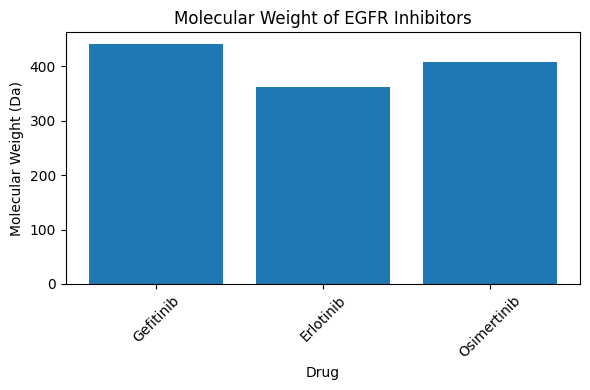

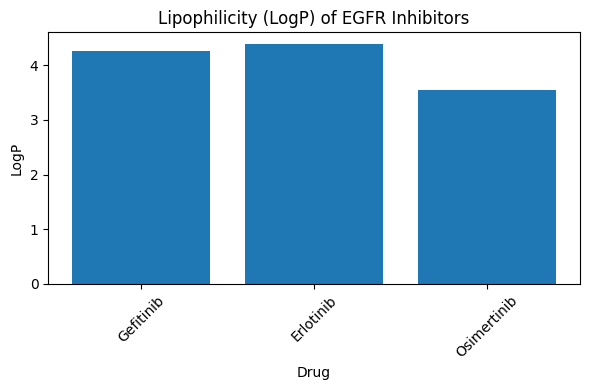

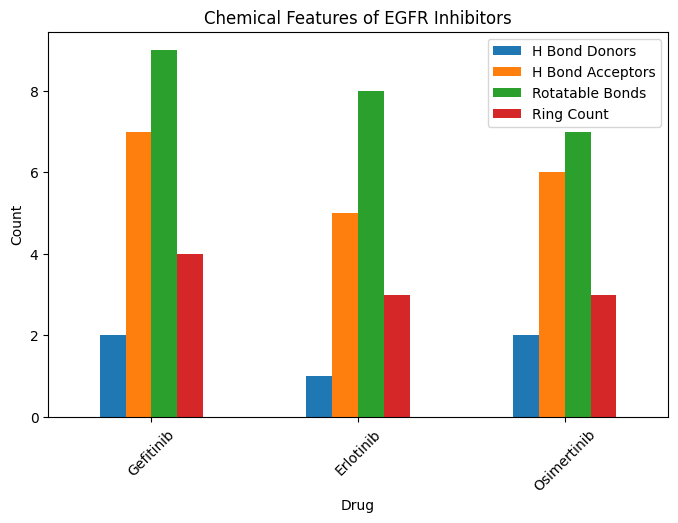

In [48]:
plot_drug_properties(df_drugs)

# Part 5

In [54]:
from Bio import SeqIO

In [57]:
amino_acid_weights = {
    "A": 89.09, "R": 174.20, "N": 132.12, "D": 133.10,
    "C": 121.15, "E": 147.13, "Q": 146.15, "G": 75.07,
    "H": 155.16, "I": 131.17, "L": 131.17, "K": 146.19,
    "M": 149.21, "F": 165.19, "P": 115.13, "S": 105.09,
    "T": 119.12, "W": 204.23, "Y": 181.19, "V": 117.15
}


def protein_analysis_from_fasta(filename):
    """
    Translate DNA sequences and calculate protein properties.

    Parameters:
        filename (str): FASTA file containing DNA sequences.

    Returns:
        dict: Protein analysis results.
    """

    protein_results = {}

    for record in SeqIO.parse(filename, "fasta"):

        # Trim incomplete codon before translation
        dna_sequence = record.seq[:len(record.seq) - len(record.seq) % 3]

        # Translate DNA to protein
        protein_sequence = str(dna_sequence.translate())

        # Remove everything after stop codon
        protein_sequence = protein_sequence.split("*")[0]


        # Protein length
        protein_length = len(protein_sequence)


        # Molecular weight calculation
        molecular_weight = sum(
            amino_acid_weights[aa]
            for aa in protein_sequence
        )


        # Amino acid composition
        amino_acid_composition = {}

        for aa in protein_sequence:

            if aa not in amino_acid_composition:
                amino_acid_composition[aa] = 1

            else:
                amino_acid_composition[aa] += 1


        # Convert counts to percentage
        for aa in amino_acid_composition:
            amino_acid_composition[aa] = (
                amino_acid_composition[aa] / protein_length
            )


        protein_results[record.id] = {

            "Protein Sequence": protein_sequence,

            "Protein Length": protein_length,

            "Molecular Weight": molecular_weight,

            "Amino Acid Composition": amino_acid_composition
        }


    return protein_results

In [58]:
filename = "EGFR.fna"

protein_results = protein_analysis_from_fasta(filename)

print(protein_results)

{'NC_000007.14:55019017-55211628': {'Protein Sequence': 'RRPGSPRRSAAAAASAPRTV', 'Protein Length': 20, 'Molecular Weight': 2377.54, 'Amino Acid Composition': {'R': 0.25, 'P': 0.15, 'G': 0.05, 'S': 0.15, 'A': 0.3, 'T': 0.05, 'V': 0.05}}, 'NC_060931.1:55178937-55372056': {'Protein Sequence': 'RRPGSPRRSAAAAASSPRTV', 'Protein Length': 20, 'Molecular Weight': 2393.54, 'Amino Acid Composition': {'R': 0.25, 'P': 0.15, 'G': 0.05, 'S': 0.2, 'A': 0.25, 'T': 0.05, 'V': 0.05}}}


In [59]:
def analyze_gene(gene_name):

    fasta_file = f"{gene_name}.fna"

    print(
        f"Starting analysis for {gene_name}"
    )

    # Sequence analysis
    sequence_lengths = calculate_sequence_lengths(
        fasta_file
    )

    print("\nSequence Length:")
    print(sequence_lengths)


    # Nucleotide composition
    nucleotide_df = calculate_nucleotide_composition(
        fasta_file
    )

    print("\nNucleotide Composition:")
    print(nucleotide_df)


    # Protein analysis
    protein_results = protein_analysis_from_fasta(
        fasta_file
    )

    print("\nProtein Analysis:")
    for seq_id, result in protein_results.items():

        print("\n", seq_id)

        print(
            "Protein Length:",
            result["Protein Length"]
        )

        print(
            "Molecular Weight:",
            result["Molecular Weight"]
        )


    print(
        f"\n{gene_name} analysis completed!"
    )

In [60]:
analyze_gene("EGFR")

Starting analysis for EGFR

Sequence Length:
{'NC_000007.14:55019017-55211628': 192612, 'NC_060931.1:55178937-55372056': 193120}

Nucleotide Composition:
   NC_000007.14:55019017-55211628  NC_060931.1:55178937-55372056
A                           52532                          52611
T                           54236                          54372
C                           43545                          43562
G                           42299                          42575

Protein Analysis:

 NC_000007.14:55019017-55211628
Protein Length: 20
Molecular Weight: 2377.54

 NC_060931.1:55178937-55372056
Protein Length: 20
Molecular Weight: 2393.54

EGFR analysis completed!
